# Differentiable Ray Tracing and Parameter Recovery

In this notebook, we perform differentiable ray tracing to compute the derivatives of the image intensity with respect to key parameters, such as:  

- Observer inclination (`θ`)
- Rhigh

We then use these derivatives to recover the ground truth parameters of our analytical test model using the conjugate gradient algorithm.  

This approach allows us to perform gradient-based parameter estimation, linking observed intensity changes directly to the underlying physical parameters.

In this notebook, we will show you how to perform the generation of the gradients. We do advise you to run the optimization via script rather than a jupyter notebook for stability.


### Loading the Julia Files

Whenever you modify any of the source files, you need to reload `main.jl`.  
The file `main.jl` serves as a **wrapper** that imports and organizes all the functions of the code, ensuring that any changes are reflected in the notebook.


In [1]:
using Jipole
using StaticArrays

const MBH = 6.2e9

6.2e9

## Now we point to the path of the GRMHD snapshot/dumpfile.

- Currently, Jipole only reads `iharm3d` data format.

To access the file used in this notebook, download the snapshot from [Harvard Dataverse (GRMHD snapshot)](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/XZECPF)

In [2]:
dump_filepath = "/home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5";

## Magnetization parameters

We begin by defining a set of parameters that will be used when reading and processing the GRMHD simulation data

- `trat_large:` Ratio of ion-to-electron temperature in low-magnetization regions (disk-dominated plasma). This controls how hot electrons are relative to ions in the bulk flow.
- `trat_small:` Ion-to-electron temperature ratio in highly magnetized regions (jet-dominated plasma). A value closer to 1 implies electrons and ions have similar temperatures.
- `beta_crit:` Critical plasma beta (ratio of gas pressure to magnetic pressure) that determines the transition between disk-like and jet-like thermodynamic prescriptions.
- `th_beg:`   Lower cutoff for the polar angle (in radians), typically used to exclude regions too close to the poles where numerical artifacts or low-density funnels may exist.
- `sigma_cut:` Magnetization threshold (σ = magnetic energy density / matter energy density) above which zones may be excluded or treated differently due to strong magnetic dominance.
- `sigma_cut_high:` Upper magnetization cutoff. A negative value typically indicates that no upper limit is enforced.

In [5]:
#TODO: put this in reading file
trat_large = 20. 
const trat_small = 1. 
const beta_crit = 1.0 
const th_beg = 1.74e-2 
const sigma_cut = 1.
const sigma_cut_high = -1.0;



## Simulation Parameters Structure
We define a `GlobalParams` structure that stores all the relevant metadata quantities describing the GRMHD simulation. These parameters are read from the simulation header and are required to interpret the data in the dump file.

### Overview

The structure includes:

- **Flags**
  - `metric`, `ELECTRONS`, `RADIATION`  
    Integer flags indicating the spacetime metric used and whether electron physics and radiation are included in the simulation.

- **Physical Parameters**
  - `gam`, `game`, `gamp`  
    Adiabatic indices for the total fluid, electrons, and protons.
  - `Te_unit`, `Thetae_unit`  
    Conversion factors for electron temperature into physical or dimensionless units.

- **Particle Weights**
  - `mu_i`, `mu_e`, `mu_tot`  
    Mean molecular weights for ions, electrons, and the total plasma.
  - `Ne_factor`  
    Scaling factor used to compute electron number density.

- **Units**
  - `M_unit`, `T_unit`, `L_unit`  
    Unit conversions for mass, time, and length.
  - `MBH`  
    Black hole mass used to scale the simulation.
  - `tp_over_te`  
    Ratio of proton to electron temperature.

- **Metric Parameters**
  - `a`  
    Dimensionless black hole spin.
  - `hslope`, `Rin`, `Rout`  
    Parameters defining the radial and angular grid structure.
  - `poly_xt`, `poly_alpha`, `mks_smooth`, `poly_norm`  
    Parameters controlling coordinate transformations and grid shaping.

- **MKS3-Specific Parameters**
  - `mks3R0`, `mks3H0`, `mks3MY1`, `mks3MY2`, `mks3MP0`  
    Additional parameters for modified Kerr–Schild (MKS3) coordinate systems.

- **Grid Configuration**
  - `N1`, `N2`, `N3`  
    Number of grid cells in each spatial dimension.
  - `dx`  
    Grid spacing in each coordinate direction.
  - `startx`, `stopx`  
    Domain boundaries.
  - `cstartx`, `cstopx`  
    Cell-centered domain boundaries.

- **Geometric Limits**
  - `rmin_geo`, `rmax_geo`  
    Minimum and maximum radii of the computational domain in geometric units.

Together, these parameters describe the simulation setup, coordinate system, physical scaling, and numerical grid.

### Choosing `M_unit`

`M_unit` sets the overall density/temperature normalization for the GRMHD dump, and therefore the entire radiative transfer calculation. Always pass it explicitly rather than relying on `read_header`'s default.

For the M87*-scale dumps used in this repo (`MBH = 6.2e9 Msun`, `D = 16.9 Mpc`), the two common GRMHD magnetic topologies use:

- **MAD** (Magnetically Arrested Disk): `M_unit = Jipole.Constants.M_UNIT_MAD` (`6.e24` g)
- **SANE** (Standard And Normal Evolution): `M_unit = Jipole.Constants.M_UNIT_SANE` (`3.e26` g -- `read_header`'s default)

In [6]:
const model = Jipole.Iharm.read_header(dump_filepath, MBH;
    th_beg=th_beg, trat_small=trat_small, beta_crit=beta_crit,
    sigma_cut=sigma_cut, sigma_cut_high=sigma_cut_high,
    M_unit=Jipole.Constants.M_UNIT_SANE); 

Initializing grid from: /home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5


Using Modified Kerr-Schild coordinates MKS
MKS parameters a: 0.937500 hslope: 0.300000 Rin: 1.177706 Rout: 1000.000000
Grid start (startx): 1.635684465252566e-01, 0.000000000000000e+00, 0.000000000000000e+00 stop (stopx): 6.907755278982137e+00, 1.000000000000000e+00, 6.283185307179586e+00
grid dx: 2.341731539047528e-02, 7.812500000000000e-03, 4.908738521234052e-02


## Simulation Data (Primitive Variables)

The simulation data structure stores the **primitive variables** extracted from the GRMHD dump file, along with some derived quantities.
### Primitive Variables
- `RHO`  
  Rest-mass density of the fluid.
- `UU`  
  Internal energy density.
- `U1`, `U2`, `U3`  
  Spatial components of the fluid 4-velocity.
- `B1`, `B2`, `B3`  
  Magnetic field components defined in the simulation frame.
### Derived Quantities
- `ne`  
  Electron number density, computed using the density and composition assumptions.
- `b`  
  Magnetic field strength (magnitude of the magnetic 4-vector).
- `θe`  
  Dimensionless electron temperature.
- `sigma`  
  Magnetization parameter (ratio of magnetic to matter energy density).
- `beta`  
  Plasma beta, defined as the ratio of gas pressure to magnetic pressure.
- `dθedRhi`  
  Radial gradient of the electron temperature in high-magnetization regions, used when doing the autodiff analysis on Rhigh

In [7]:
const simulation_data = Vector{Jipole.Iharm.IharmData{Array{Float64, 3}}}(undef, 1)
simulation_data[1] = Jipole.Iharm.load_data(dump_filepath, trat_large, model);

Loading data from '/home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'Iharm' module...
All primitives successfully loaded. Dimensions: (288, 128, 128)


In [8]:
# Observer distance in gravitational radii (Rg)
const ro = 1000.0

# Inclination angle (deg) — angle between the observer and the BH spin axis
const th = 163.0

# Azimuthal angle (deg) — rotation around the system
const phi = 0.0

# Image resolution — total geodesics traced = res^2
const res = 128
const pixels_x = 128
const pixels_y = 128

# Distance to the source (in parsecs, converted to code units)
const SourceD = 16.9e6 * Jipole.Constants.PC

# Radius where ray integration stops
const Rstop = 100.0

# Event horizon radius for a Kerr black hole
const Rh = 1 + sqrt(1. - model.a * model.a)

# Observing frequency (Hz), e.g. 230 GHz for EHT-like images
const freq = 230e9

# Image plane size (in Rg), scaled from physical distance
const DXsize = SourceD / model.L_unit / Jipole.Constants.MUAS_PER_RAD * 160
const DYsize = SourceD / model.L_unit / Jipole.Constants.MUAS_PER_RAD * 160

# Field of view (radians)
const fovx = DXsize / ro
const fovy = DYsize / ro

# Image offsets (can be used to shift the camera)
const xoff = 0.0
const yoff = 0.0

#Number of maximum steps in the geodesic calculation
const maxnstep = 15000;

In [9]:
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)

const DX = DXsize
const DY = DYsize
const total_pixels = pixels_x * pixels_y

# Pre-allocate output arrays
dI_dθo_arr = Matrix{Float64}(undef, pixels_x, pixels_y)
dI_dRhigh_arr = Matrix{Float64}(undef, pixels_x, pixels_y)
I_arr = Matrix{Float64}(undef, pixels_x, pixels_y)

# Number of threads used in the calculation
const nthreads = Threads.nthreads()

# Pre-allocate memory buffers once per thread using sizehint!
# This reserves contiguous memory for maxnstep elements
thread_trajs = [sizehint!(Vector{Jipole.GeoTypes.OfTraj}(), maxnstep) for _ in 1:nthreads+1]

# Progress tracking with chunk-based updates
const CHUNK_SIZE = 100  # Update every 100 pixels
progress_counter = Threads.Atomic{Int}(0)
p = Progress(total_pixels; 
            desc="Computing Image and Sensitivity...", 
            showspeed=true, 
            barlen=30)

# Flatten loop for better load balancing
Threads.@threads :greedy for idx in 1:total_pixels
tid = Threads.threadid()

# Convert flat index to (i, j)
i = (idx - 1) ÷ pixels_x
j = (idx - 1) % pixels_y

# Empty the trajectory vector for this pixel (does not deallocate memory)
empty!(thread_trajs[tid])

# Compute references
dI_dθo_out = Ref{Float64}(0.0)
intensity_out = Ref{Float64}(0.0)
dI_dRhigh_out = Ref{Float64}(0.0)

Jipole.Autodiff.autodiff_geo_traj_euler_method_grmhd!(
    thread_trajs[tid], dI_dθo_out, intensity_out, dI_dRhigh_out,
    ro, th, phi, model.a, pixels_x, pixels_y, maxnstep, i, j, 
    freq, fovx, fovy, model, Rstop, simulation_data
)

# Store results
dI_dRhigh_arr[i + 1, j + 1] = dI_dRhigh_out[]
dI_dθo_arr[i + 1, j + 1] = dI_dθo_out[]
I_arr[i + 1, j + 1] = intensity_out[]

# Update progress every CHUNK_SIZE pixels
if idx % CHUNK_SIZE == 0
    count = Threads.atomic_add!(progress_counter, CHUNK_SIZE)
    ProgressMeter.update!(p, count)
end
end

# Final update to ensure we reach 100%
final_count = Threads.atomic_add!(progress_counter, 0) 
if final_count < total_pixels
ProgressMeter.update!(p, total_pixels)
end

finish!(p)

Computing Image and Sensitivity... 100%|██████████████████████████████| Time: 0:01:22 ( 5.04 ms/it)


## Differentiate the ODE as well

In [11]:
using ForwardDiff
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)

DualT = ForwardDiff.Dual{Nothing,Float64,1}
task_trajs = [Vector{Jipole.GeoTypes.OfTrajDual{DualT}}(undef, maxnstep) for _ in 1:pixels_x]

I_image = zeros(Float64, pixels_x, pixels_y)
dI_dtheta = zeros(Float64, pixels_x, pixels_y)

p = Progress(pixels_x * pixels_y; desc = "Computing image + dI/dθo...", showspeed = true, barlen = 30)
ProgressMeter.ijulia_behavior(:clear)
progress_lock = ReentrantLock()

println("Computing image and θo-sensitivity...")
Threads.@threads :greedy for i in 0:(pixels_x - 1)
    my_traj = task_trajs[i + 1]

    for j in 0:(pixels_y - 1)
        I_val, dI_val = Jipole.Autodiff.differentiate_pixel_intensity(
            th, i, j, model.a, model, simulation_data,
            ro, phi, pixels_x, pixels_y, fovx, fovy, freq, Rstop, maxnstep, my_traj
        )
        I_image[i + 1, j + 1] = I_val
        dI_dtheta[i + 1, j + 1] = dI_val
        lock(progress_lock) do
            if (i * pixels_y + j) % 2000 == 0
                ProgressMeter.next!(p; showvalues = [
                    (:pixel, "($i, $j)"),
                    (:total_done, "$(i*pixels_y + j)/$(pixels_x * pixels_y)")
                ])
            else
                ProgressMeter.next!(p)
            end
        end
    end
end
finish!(p)

Computing image and θo-sensitivity...


Computing image + dI/dθo... 100%|██████████████████████████████| Time: 0:00:06 ( 0.39 ms/it)


# Plotting the Image

### Image and Sensitivity Maps

This figure shows a **1×3 panel visualization** of the simulated image and its parameter sensitivities. The horizontal and vertical axes correspond to the **angular coordinates on the sky (in μas)**.


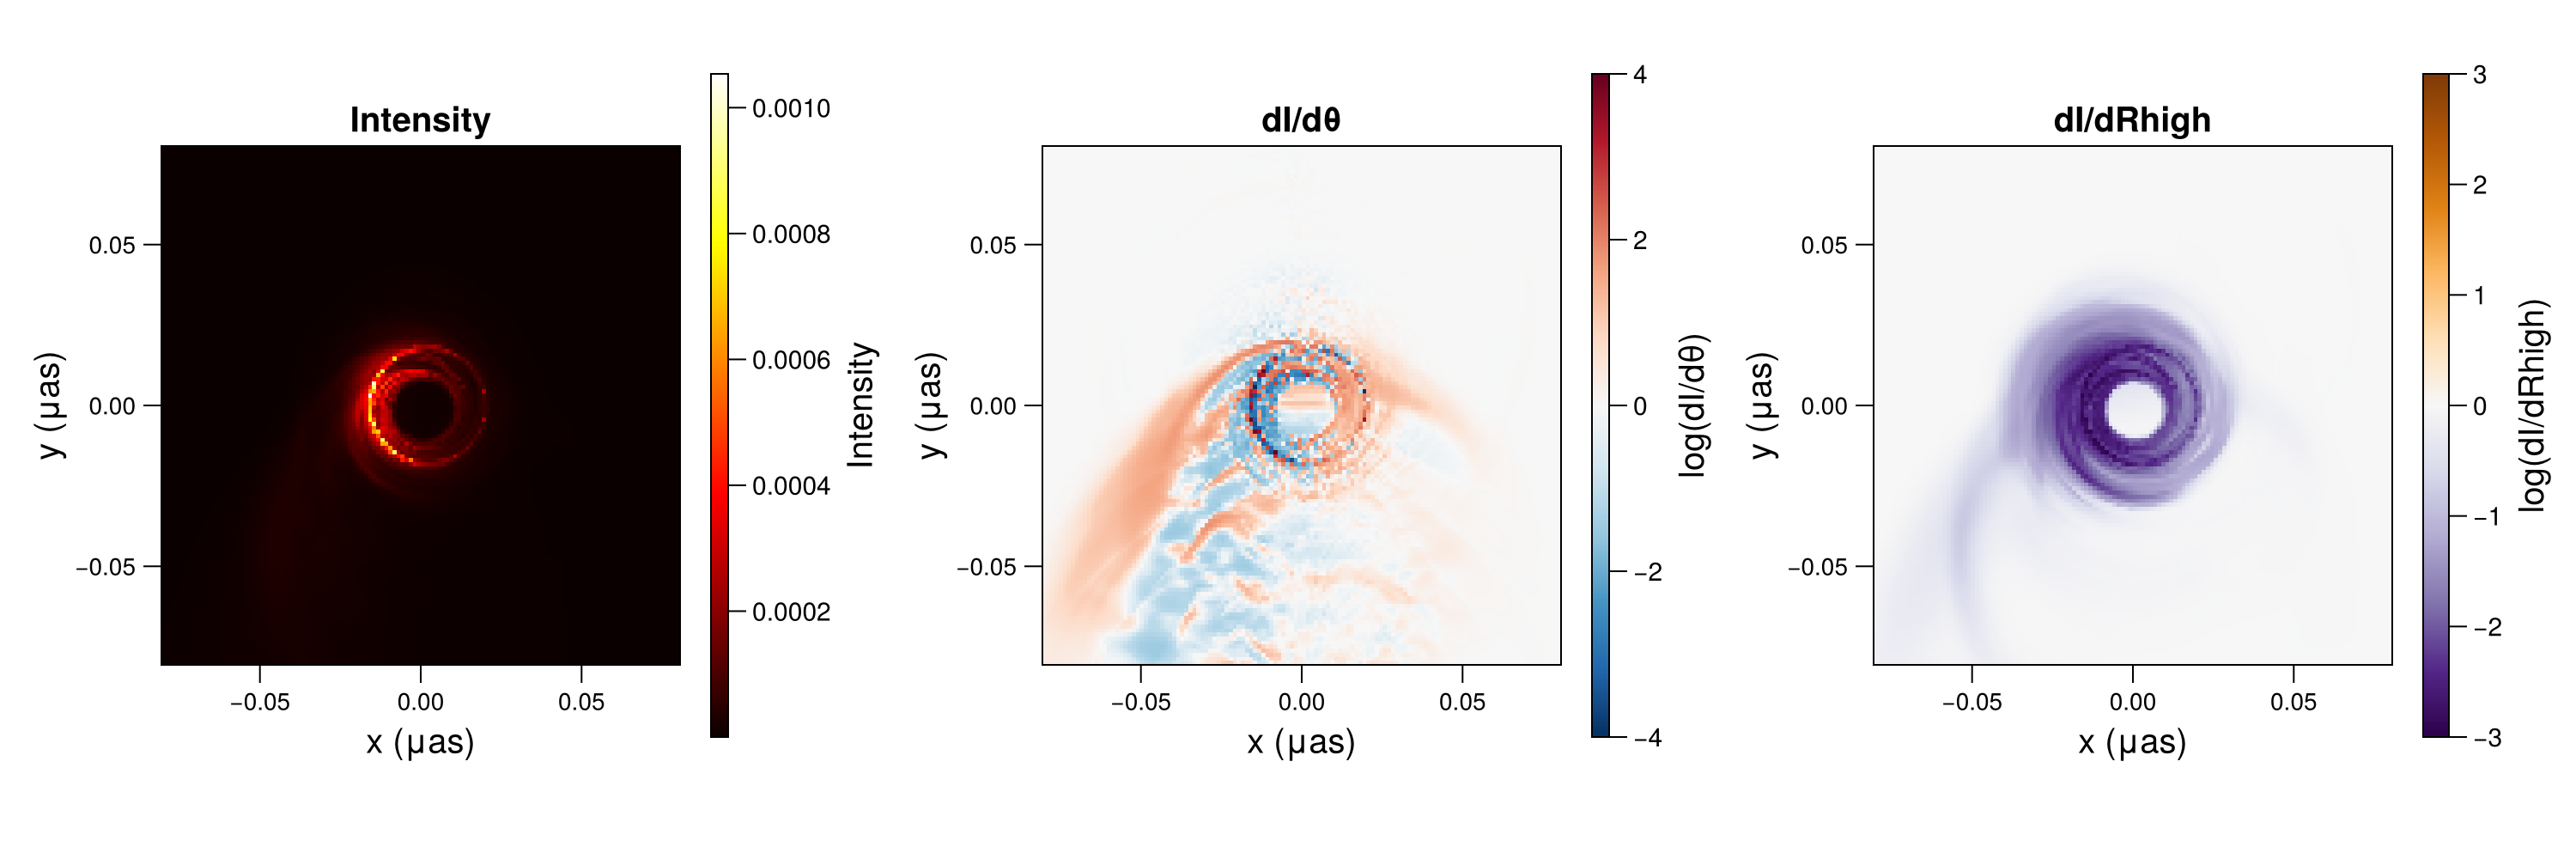

In [8]:
using CairoMakie

d_kpc = 16900
d_cm = d_kpc * 3.086e21
fov_rg = fovx
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * model.L_unit) / d_cm
theta_μas = theta_rad * Jipole.Constants.MUAS_PER_RAD

x_coords = range(-theta_μas, theta_μas, length=pixels_x)
y_coords = range(-theta_μas, theta_μas, length=pixels_y)


function symlog(x; linthresh)
    absx = abs.(x)
    signx = sign.(x)
    y = similar(x)
    mask = absx .<= linthresh
    y[mask] .= x[mask] ./ linthresh
    y[.!mask] .= signx[.!mask] .* (1 .+ log10.(absx[.!mask] ./ linthresh))
    return y
end


axis_tick_size = 14
colorbar_tick_size = 15
colorbar_label_size = 20


vmin_theta = -1e-3
vmax_theta =  1e-3
linthresh_theta = 1e-3 * vmax_theta

dI_dθ_symlog = symlog(dI_dθo_arr; linthresh=linthresh_theta)
cr_symlog_theta = (
    -(1 + log10(abs(vmin_theta) / linthresh_theta)),
     (1 + log10(abs(vmax_theta) / linthresh_theta))
)

max_val_R = maximum(abs.(filter(!isnan, dI_dRhigh_arr))) 
if max_val_R == 0; max_val_R = 1.0; end 

vmin_R = -max_val_R
vmax_R =  max_val_R
linthresh_R = 1e-2 * vmax_R 

dI_dR_symlog = symlog(dI_dRhigh_arr; linthresh=linthresh_R)
cr_symlog_R = (
    -(1 + log10(abs(vmin_R) / linthresh_R)),
     (1 + log10(abs(vmax_R) / linthresh_R))
)

fig = Figure(size = (1500, 500)) 

ax1 = Axis(fig[1, 1],
    title = "Intensity",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = axis_tick_size,
    yticklabelsize = axis_tick_size,
    xticksize = 10, yticksize = 10 
)

hm1 = heatmap!(ax1, x_coords, y_coords, I_arr; colormap = :hot)
cb1 = Colorbar(fig[1, 2], hm1; 
    label = "Intensity",
    labelsize = colorbar_label_size,   
    ticklabelsize = colorbar_tick_size, 
    ticksize = 10,                    
    width = 10                         
)


ax2 = Axis(fig[1, 3],
    title = "dI/dθ",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = axis_tick_size,
    yticklabelsize = axis_tick_size,
    xticksize = 10, yticksize = 10 
)
hm2 = heatmap!(ax2, x_coords, y_coords, dI_dθ_symlog;
    colormap = Reverse(:RdBu),
    colorrange = cr_symlog_theta
)
cb2 = Colorbar(fig[1, 4], hm2; 
    label = "log(dI/dθ)",
    labelsize = colorbar_label_size,   
    ticklabelsize = colorbar_tick_size,
    ticksize = 10,                     
    width = 10                        
)
ax3 = Axis(fig[1, 5],
    title = "dI/dRhigh",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = axis_tick_size,
    yticklabelsize = axis_tick_size,
    xticksize = 10, yticksize = 10 
)

hm3 = heatmap!(ax3, x_coords, y_coords, dI_dR_symlog;
    colormap = Reverse(:PuOr), 
    colorrange = cr_symlog_R
)

cb3 = Colorbar(fig[1, 6], hm3; 
    label = "log(dI/dRhigh)",
    labelsize = colorbar_label_size,   
    ticklabelsize = colorbar_tick_size, 
    ticksize = 10,                     
    width = 15                        
)

fig

# GPU version

In [1]:
using Jipole
using StaticArrays

const MBH = 6.2e9

6.2e9

In [2]:
dump_filepath ="/home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5"


"/home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5"

In [3]:
trat_large = 20. 
const trat_small = 1. 
const beta_crit = 1.0 
const th_beg = 1.74e-2 
const sigma_cut = 1.e99
const sigma_cut_high = -1.0;

In [4]:
const model = Jipole.Iharm.read_header(dump_filepath, MBH;
    th_beg=th_beg, trat_small=trat_small, beta_crit=beta_crit,
    sigma_cut=sigma_cut, sigma_cut_high=sigma_cut_high,
    M_unit=Jipole.Constants.M_UNIT_SANE);  # SANE dump -- see the M_unit note above

Initializing grid from: /home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5


Using Modified Kerr-Schild coordinates MKS
MKS parameters a: 0.937500 hslope: 0.300000 Rin: 1.177706 Rout: 1000.000000
Grid start (startx): 1.635684465252566e-01, 0.000000000000000e+00, 0.000000000000000e+00 stop (stopx): 6.907755278982137e+00, 1.000000000000000e+00, 6.283185307179586e+00
grid dx: 2.341731539047528e-02, 7.812500000000000e-03, 4.908738521234052e-02


In [5]:
const simulation_data = Vector{Jipole.Iharm.IharmData{Array{Float64, 3}}}(undef, 1)
simulation_data[1] = Jipole.Iharm.load_data(dump_filepath, trat_large, model);

Loading data from '/home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'Iharm' module...
All primitives successfully loaded. Dimensions: (288, 128, 128)


In [6]:
# Observer distance in gravitational radii (Rg)
const ro = 1000.0

# Inclination angle (deg) — angle between the observer and the BH spin axis
const th = 163.0

# Azimuthal angle (deg) — rotation around the system
const phi = 0.0

# Image resolution — total geodesics traced = res^2
const res = 128
const pixels_x = 128
const pixels_y = 128

# Distance to the source (in parsecs, converted to code units)
const SourceD = 16.9e6 * Jipole.Constants.PC

# Radius where ray integration stops
const Rstop = 100.0

# Event horizon radius for a Kerr black hole
const Rh = 1 + sqrt(1. - model.a * model.a)

# Observing frequency (Hz), e.g. 230 GHz for EHT-like images
const freq = 230e9

# Image plane size (in Rg), scaled from physical distance
const DXsize = SourceD / model.L_unit / Jipole.Constants.MUAS_PER_RAD * 160
const DYsize = SourceD / model.L_unit / Jipole.Constants.MUAS_PER_RAD * 160

# Field of view (radians)
const fovx = DXsize / ro
const fovy = DYsize / ro

# Image offsets (can be used to shift the camera)
const xoff = 0.0
const yoff = 0.0

#Number of maximum steps in the geodesic calculation
const maxnstep = 15000;

In [9]:
using CUDA
#First, we clear the arrays
d_Image = nothing
d_dI_dθo = nothing
d_dI_dRhigh = nothing
d_traj = nothing
gpu_sim_data = nothing

# Then we allocate Image
d_Image       = CUDA.zeros(Float64, pixels_x, pixels_y)
d_dI_dθo      = CUDA.zeros(Float64, pixels_x, pixels_y)
d_dI_dRhigh   = CUDA.zeros(Float64, pixels_x, pixels_y)
block_size = 64
d_traj = CuArray{Jipole.GeoTypes.OfTrajGRMHD}(undef, block_size, block_size, maxnstep)
threads_per_block = (4, 4)
blocks_per_grid   = (cld(block_size, threads_per_block[1]), cld(block_size, threads_per_block[2]))

println("Copying simulation data grids to the GPU...")

gpu_sim_data = (Jipole.Utils_GPU.copy_iharm_to_gpu(simulation_data[1]),)
gpu_params = model;

Copying simulation data grids to the GPU...


In [10]:
println("Processing image in tiles...")

CUDA.@time begin
    # Loop over the image grid in steps of block_size
    for i_offset in 0:block_size:(pixels_x - 1)
        for j_offset in 0:block_size:(pixels_y - 1)
            
            @cuda threads=threads_per_block blocks=blocks_per_grid Jipole.Autodiff.raytrace_gradients_gpu!(
                d_traj, d_Image,d_dI_dθo, d_dI_dRhigh,
                i_offset, j_offset, block_size, block_size,
                ro, th, phi, model.a, pixels_x, pixels_y, maxnstep,
                freq, fovx, fovy, model.Rout, Rstop, gpu_sim_data, gpu_params
            )
            
        end
    end
    CUDA.synchronize()
end

h_Image = Array(d_Image)
h_dI_dth = Array(d_dI_dθo)
h_dI_drhigh = Array(d_dI_dRhigh)

println("Raytracing complete!")

Processing image in tiles...
  7.040986 seconds (1.01 k CPU allocations: 48.750 KiB, 0.03% gc time)
Raytracing complete!


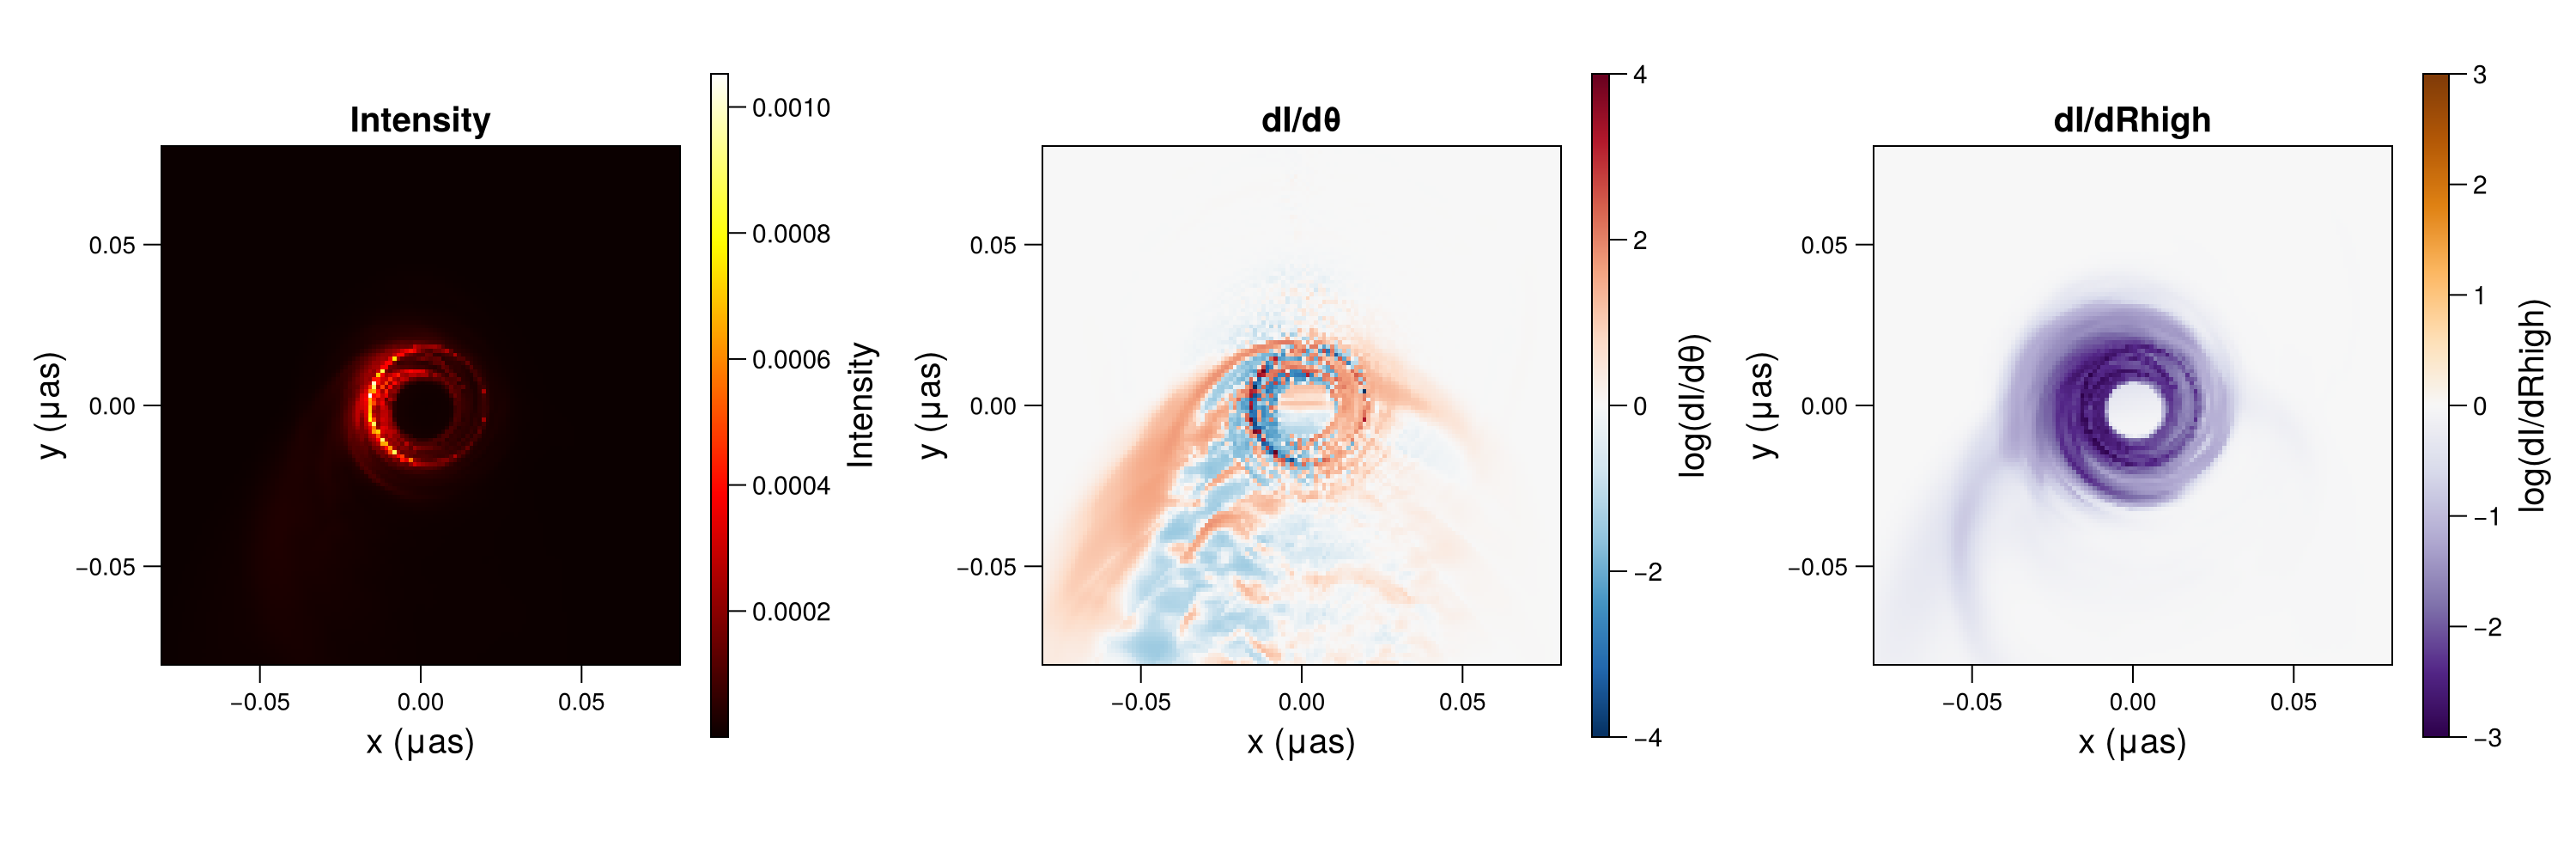

In [11]:
using CairoMakie

d_kpc = 16900
d_cm = d_kpc * 3.086e21
fov_rg = fovx
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * model.L_unit) / d_cm
theta_μas = theta_rad * Jipole.Constants.MUAS_PER_RAD

x_coords = range(-theta_μas, theta_μas, length=pixels_x)
y_coords = range(-theta_μas, theta_μas, length=pixels_y)


function symlog(x; linthresh)
    absx = abs.(x)
    signx = sign.(x)
    y = similar(x)
    mask = absx .<= linthresh
    y[mask] .= x[mask] ./ linthresh
    y[.!mask] .= signx[.!mask] .* (1 .+ log10.(absx[.!mask] ./ linthresh))
    return y
end


axis_tick_size = 14
colorbar_tick_size = 15
colorbar_label_size = 20


vmin_theta = -1e-3
vmax_theta =  1e-3
linthresh_theta = 1e-3 * vmax_theta

dI_dθ_symlog = symlog(h_dI_dth; linthresh=linthresh_theta)
cr_symlog_theta = (
    -(1 + log10(abs(vmin_theta) / linthresh_theta)),
     (1 + log10(abs(vmax_theta) / linthresh_theta))
)

max_val_R = maximum(abs.(filter(!isnan, h_dI_drhigh))) 
if max_val_R == 0; max_val_R = 1.0; end 

vmin_R = -max_val_R
vmax_R =  max_val_R
linthresh_R = 1e-2 * vmax_R 

dI_dR_symlog = symlog(h_dI_drhigh; linthresh=linthresh_R)
cr_symlog_R = (
    -(1 + log10(abs(vmin_R) / linthresh_R)),
     (1 + log10(abs(vmax_R) / linthresh_R))
)

fig = Figure(size = (1500, 500)) 

ax1 = Axis(fig[1, 1],
    title = "Intensity",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = axis_tick_size,
    yticklabelsize = axis_tick_size,
    xticksize = 10, yticksize = 10 
)

hm1 = heatmap!(ax1, x_coords, y_coords, h_Image; colormap = :hot)
cb1 = Colorbar(fig[1, 2], hm1; 
    label = "Intensity",
    labelsize = colorbar_label_size,   
    ticklabelsize = colorbar_tick_size, 
    ticksize = 10,                    
    width = 10                         
)


ax2 = Axis(fig[1, 3],
    title = "dI/dθ",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = axis_tick_size,
    yticklabelsize = axis_tick_size,
    xticksize = 10, yticksize = 10 
)
hm2 = heatmap!(ax2, x_coords, y_coords, dI_dθ_symlog;
    colormap = Reverse(:RdBu),
    colorrange = cr_symlog_theta
)
cb2 = Colorbar(fig[1, 4], hm2; 
    label = "log(dI/dθ)",
    labelsize = colorbar_label_size,   
    ticklabelsize = colorbar_tick_size,
    ticksize = 10,                     
    width = 10                        
)
ax3 = Axis(fig[1, 5],
    title = "dI/dRhigh",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = axis_tick_size,
    yticklabelsize = axis_tick_size,
    xticksize = 10, yticksize = 10 
)

hm3 = heatmap!(ax3, x_coords, y_coords, dI_dR_symlog;
    colormap = Reverse(:PuOr), 
    colorrange = cr_symlog_R
)

cb3 = Colorbar(fig[1, 6], hm3; 
    label = "log(dI/dRhigh)",
    labelsize = colorbar_label_size,   
    ticklabelsize = colorbar_tick_size, 
    ticksize = 10,                     
    width = 15                        
)

fig